# Notebook 06 — Robustness: cross-asset, likelihood, and cost-sensitivity

**Inputs:** cached SPY traces / paths / classical baselines from nb 03 – 05;
TLT raw prices from `data/raw/`.

**Outputs:** new caches under `data/processed/{traces,paths,classical}/` for
the TLT pipeline (Gaussian sampler + 500 posterior rollouts + 3 classical
baselines × 20 seeds).

**Runtime budget:** ≤ 90 s warm. First-run cold pass dominated by the TLT
Gibbs fit (~3 – 5 min) plus the classical baselines on TLT (~30 – 60 s).

**Purpose.** Notebook 05 reported *"on SPY 2020-04 → 2026, with this prior
choice and this cost model, here's what we observe."* This notebook
stress-tests three of those qualifiers:

- **Asset choice (Panel A).** Does the conclusion hold on **TLT** (long-bond
  ETF), an instrument with a different return distribution and a different
  volatility regime?
- **Likelihood (Panel B).** Does the **Student-t** variant — which gives the
  posterior an explicit heavy-tail accommodation — change the empirical
  ranking we reported on SPY?
- **Cost model (Panel C).** Holding the trained policies fixed, how
  sensitive are the realized metrics to the **transaction-cost
  multiplier**?

The reviewer's question this notebook anticipates: *"how much of your
conclusion depends on lucky choices?"* The honest answer might be *"some
of it"* — and that's still a valuable conclusion, communicated honestly.
The closing cell synthesizes across all three panels.


In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle
import time

import numpy as np
import pandas as pd
from IPython.display import display

from project import baselines, data, env, features, plots, priors, rollout, sampler, thompson
from project import eval as ev
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()

SEED      = 12345
N_PATHS   = 500
N_SEEDS   = 20
BASE_SEED = 0

GIBBS_KWARGS = dict(n_draws=6000, n_burn=2000, n_chains=4, seed=SEED)

TRACE_DIR     = Path("../data/processed/traces")
PATHS_DIR     = Path("../data/processed/paths")
CLASSICAL_DIR = Path("../data/processed/classical")
for d in (TRACE_DIR, PATHS_DIR, CLASSICAL_DIR):
    d.mkdir(parents=True, exist_ok=True)


## Test-window data: SPY (cached) and TLT (new)

Both assets share the proposal's split — train 1994-01-01 → 2019-12-31, test
2020-01-01 → 2026-04-30 — but TLT's launch on 2002-07-22 means its
*effective* training window is shorter. We do not adjust the train window
or the sampler budget: the goal is to ask whether the same pipeline applied
to a different asset reaches the same conclusion, not to engineer matched
conditions. Smaller-N training is itself a robustness dimension, and any
widening of the TLT credible bands relative to SPY's is a feature of
Bayesian inference correctly reflecting reduced data.


In [2]:
spy             = data.load_spy()
tlt             = data.load_tlt()
splits_spy      = data.split_windows(spy)
splits_tlt      = data.split_windows(tlt)

prices_train_spy = splits_spy["train"]
prices_test_spy  = splits_spy["test"]
prices_train_tlt = splits_tlt["train"]
prices_test_tlt  = splits_tlt["test"]

feat_spy        = features.build_features(spy)
feat_tlt        = features.build_features(tlt)
feat_train_spy  = feat_spy.reindex(prices_train_spy.index)
feat_test_spy   = feat_spy.reindex(prices_test_spy.index)
feat_train_tlt  = feat_tlt.reindex(prices_train_tlt.index)
feat_test_tlt   = feat_tlt.reindex(prices_test_tlt.index)

def _window_summary(name: str, prices: pd.DataFrame, feat_train: pd.DataFrame) -> None:
    valid = feat_train.dropna()
    print(f"{name:>4} train: {prices.index[0].date()} -> {prices.index[-1].date()}  "
          f"({len(prices):>5} rows; {len(valid):>5} after warmup)")

_window_summary("SPY", prices_train_spy, feat_train_spy)
_window_summary("TLT", prices_train_tlt, feat_train_tlt)
print(f" SPY  test: {prices_test_spy.index[0].date()} -> {prices_test_spy.index[-1].date()}  "
      f"({len(prices_test_spy):>5} rows)")
print(f" TLT  test: {prices_test_tlt.index[0].date()} -> {prices_test_tlt.index[-1].date()}  "
      f"({len(prices_test_tlt):>5} rows)")


 SPY train: 1994-01-03 -> 2019-12-31  ( 6546 rows;  6508 after warmup)
 TLT train: 2002-07-30 -> 2019-12-31  ( 4387 rows;  4115 after warmup)
 SPY  test: 2020-01-02 -> 2026-04-29  ( 1589 rows)
 TLT  test: 2020-01-02 -> 2026-04-29  ( 1589 rows)


## Panel A — Cross-asset robustness on TLT

We rerun the **full SPY pipeline** on TLT: Gaussian Gibbs on the TLT train
window, 500 per-episode posterior rollouts on the TLT test window, and the
three classical baselines (random, tabular Q, linear FQI) × 20 seeds. The
caches are populated as a side-effect of this notebook so subsequent reruns
are fast.

The reviewer's framing: *if SPY supports a Bayesian-vs-classical
conclusion, does TLT? If yes, the conclusion is asset-invariant. If no,
the conclusion is conditional on SPY-specific structure — still
informative, but qualified.*


In [3]:
# ---- Cache helpers (TLT-prefixed filenames; no clash with SPY caches) ----
def _trace_cache_key(name: str, asset: str, X, y, a, **kwargs) -> Path:
    h = hashlib.sha256()
    h.update(X.tobytes()); h.update(y.tobytes()); h.update(a.tobytes())
    for k, v in sorted(kwargs.items()):
        h.update(f"{k}={v!r}".encode())
    return TRACE_DIR / f"{name}_{asset}_{h.hexdigest()[:12]}.pkl"

def _load_or_run_trace(name, asset, fn, X, y, a, prior_obj, **kwargs):
    key = _trace_cache_key(name, asset, X, y, a, **kwargs)
    if key.exists():
        with open(key, "rb") as f: return pickle.load(f), key.stem.rsplit("_", 1)[-1], True
    trace = fn(X, y, a, prior_obj, **kwargs)
    with open(key, "wb") as f: pickle.dump(trace, f)
    return trace, key.stem.rsplit("_", 1)[-1], False

def _path_cache_key(asset, sampler_name, trace_hash, n_paths, resample_every, seed) -> Path:
    h = hashlib.sha256()
    h.update(trace_hash.encode())
    h.update(f"n_paths={n_paths}|resample_every={resample_every}|seed={seed}".encode())
    return PATHS_DIR / f"paths_{sampler_name}_{asset}_{h.hexdigest()[:12]}.pkl"

def _run_paths(policy, prices, feats, *, n_paths, seed, resample_every=None):
    seed_seq = np.random.SeedSequence(seed)
    path_seeds = [int(ss.generate_state(1)[0]) for ss in seed_seq.spawn(n_paths)]
    n_t = len(prices)
    actions = np.zeros((n_paths, n_t), dtype=int)
    rewards = np.full((n_paths, n_t), np.nan, dtype=float)
    cum     = np.full((n_paths, n_t), np.nan, dtype=float)
    for i, ps in enumerate(path_seeds):
        out = rollout.simulate_path(policy, prices, feats, seed=ps, resample_every=resample_every)
        actions[i] = out["actions"].to_numpy()
        rewards[i] = out["rewards"].to_numpy()
        cum[i]     = out["cum_log_return"].to_numpy()
    return {"actions": actions, "rewards": rewards, "cum_log_return": cum, "index": prices.index}

def _load_or_run_paths(asset, sampler_name, policy, trace_hash, prices, feats,
                       *, n_paths, seed, resample_every=None):
    key = _path_cache_key(asset, sampler_name, trace_hash, n_paths, resample_every, seed)
    if key.exists():
        with open(key, "rb") as f: return pickle.load(f), key, True
    out = _run_paths(policy, prices, feats, n_paths=n_paths, seed=seed, resample_every=resample_every)
    with open(key, "wb") as f: pickle.dump(out, f)
    return out, key, False

def _build_regression_inputs(prices_tr, feat_tr, rng):
    n_actions = len(env.ACTIONS)
    behavior_idx = rng.integers(0, n_actions, size=len(prices_tr))
    labels = np.asarray(env.ACTIONS, dtype=int)
    behavior_labels = labels[behavior_idx]
    train_rewards = env.step_reward(prices_tr, behavior_labels)
    from project.targets import mc_returns
    y_series = mc_returns(train_rewards)
    shared_idx = feat_tr.dropna().index.intersection(y_series.index)
    X = feat_tr.loc[shared_idx].to_numpy(dtype=float)
    y_arr = y_series.loc[shared_idx].to_numpy(dtype=float)
    behavior_idx_series = pd.Series(behavior_idx, index=prices_tr.index)
    a_arr = behavior_idx_series.loc[shared_idx].to_numpy().astype(np.int64)
    return X, y_arr, a_arr

def _bayes_metrics_from_paths(paths_dict, n_paths):
    sharpes = np.array([ev.sharpe(pd.Series(paths_dict["rewards"][i], index=paths_dict["index"]))
                        for i in range(n_paths)])
    mdds = np.array([ev.max_drawdown(pd.Series(paths_dict["cum_log_return"][i], index=paths_dict["index"]))
                     for i in range(n_paths)])
    turns = np.array([ev.turnover(pd.Series(paths_dict["actions"][i], index=paths_dict["index"]))
                      for i in range(n_paths)])
    summary = {
        "sharpe":       {"mean": float(sharpes.mean()), "q025": float(np.quantile(sharpes, 0.025)), "q975": float(np.quantile(sharpes, 0.975))},
        "max_drawdown": {"mean": float(mdds.mean()),    "q025": float(np.quantile(mdds, 0.025)),    "q975": float(np.quantile(mdds, 0.975))},
        "turnover":     {"mean": float(turns.mean()),   "q025": float(np.quantile(turns, 0.025)),   "q975": float(np.quantile(turns, 0.975))},
    }
    return summary, sharpes, mdds, turns

# ---- TLT Gaussian fit ---------------------------------------------------
rng_local = np.random.default_rng(SEED)
X_tlt, y_tlt, a_tlt = _build_regression_inputs(prices_train_tlt, feat_train_tlt, rng_local)
sigma_y_hat_tlt = float(y_tlt.std(ddof=1))
prior_g_tlt = priors.make_priors(sigma_y_hat=sigma_y_hat_tlt, p=X_tlt.shape[1], n_actions=len(env.ACTIONS))

t0 = time.time()
trace_g_tlt, hash_g_tlt, hit_g_tlt = _load_or_run_trace(
    "gaussian", "TLT", sampler.gibbs_gaussian, X_tlt, y_tlt, a_tlt, prior_g_tlt, **GIBBS_KWARGS,
)
print(f"TLT Gaussian sampler: {'cache hit' if hit_g_tlt else 'fresh run'} in {time.time() - t0:.1f}s")
print(f"  N={len(y_tlt):,}  sigma_y_hat={sigma_y_hat_tlt:.4f}  trace_hash={hash_g_tlt}")

policy_g_tlt = thompson.policy_from_trace(trace_g_tlt)

t0 = time.time()
paths_g_tlt, key_p_tlt, hit_p_tlt = _load_or_run_paths(
    "TLT", "gaussian", policy_g_tlt, hash_g_tlt, prices_test_tlt, feat_test_tlt,
    n_paths=N_PATHS, seed=SEED, resample_every=None,
)
print(f"TLT Bayesian rollouts: {'cache hit' if hit_p_tlt else 'fresh run'} in {time.time() - t0:.1f}s")
print(f"  paths shape = {paths_g_tlt['actions'].shape}")

bayes_metrics_tlt, bayes_sharpes_tlt, bayes_mdds_tlt, bayes_turns_tlt = _bayes_metrics_from_paths(paths_g_tlt, N_PATHS)
for k, v in bayes_metrics_tlt.items():
    print(f"  TLT Bayesian {k:>12}:  mean={v['mean']:+.3f}  95% CrI=[{v['q025']:+.3f}, {v['q975']:+.3f}]")

# ---- Also load SPY caches for the synthesis cell ------------------------
def _load_first_match(directory, pattern):
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern} under {directory}/")
    with open(matches[0], "rb") as f: return pickle.load(f), matches[0]

trace_g_spy, _ = _load_first_match(TRACE_DIR, "gaussian_[0-9a-f]*.pkl")
paths_g_spy, _ = _load_first_match(PATHS_DIR, "paths_gaussian_[0-9a-f]*.pkl")
bayes_metrics_spy, bayes_sharpes_spy, bayes_mdds_spy, bayes_turns_spy = _bayes_metrics_from_paths(paths_g_spy, paths_g_spy["actions"].shape[0])
print()
for k, v in bayes_metrics_spy.items():
    print(f"  SPY Bayesian {k:>12}:  mean={v['mean']:+.3f}  95% CrI=[{v['q025']:+.3f}, {v['q975']:+.3f}]")


TLT Gaussian sampler: cache hit in 0.0s
  N=4,054  sigma_y_hat=0.0318  trace_hash=c5570bc81bdc
TLT Bayesian rollouts: cache hit in 0.0s
  paths shape = (500, 1589)


  TLT Bayesian       sharpe:  mean=-1.498  95% CrI=[-2.387, -0.035]
  TLT Bayesian max_drawdown:  mean=+0.728  95% CrI=[+0.057, +1.512]
  TLT Bayesian     turnover:  mean=+0.092  95% CrI=[+0.006, +0.186]



  SPY Bayesian       sharpe:  mean=-1.520  95% CrI=[-2.580, -0.313]
  SPY Bayesian max_drawdown:  mean=+1.521  95% CrI=[+0.183, +2.776]
  SPY Bayesian     turnover:  mean=+0.134  95% CrI=[+0.015, +0.252]


### Classical baselines on TLT — random, tabular Q, linear FQI × 20 seeds

Same orchestration helper as nb 05: each baseline is fit on the TLT train
window 20 times under independent seeds; per-seed Sharpe / max-drawdown /
turnover are stacked, and we report the 2.5 – 97.5 percentile range across
seeds. This is the *raw seed distribution*, the honest comparison interval
for the classical methods.


In [4]:
# ---- Classical orchestration (mirrors nb 05) ----------------------------
def _data_fingerprint(prices_tr, prices_te) -> str:
    h = hashlib.sha256()
    h.update(f"train={prices_tr.index[0]}|{prices_tr.index[-1]}|n={len(prices_tr)}".encode())
    h.update(f"test={prices_te.index[0]}|{prices_te.index[-1]}|n={len(prices_te)}".encode())
    return h.hexdigest()[:12]

def _classical_cache_key(baseline_name, asset, fingerprint, n_seeds, base_seed, **kwargs) -> Path:
    h = hashlib.sha256()
    h.update(fingerprint.encode())
    h.update(f"n_seeds={n_seeds}|base_seed={base_seed}".encode())
    for k, v in sorted(kwargs.items()):
        h.update(f"{k}={v}".encode())
    return CLASSICAL_DIR / f"classical_{baseline_name}_{asset}_{h.hexdigest()[:12]}.pkl"

def _seed_summary(values):
    return {"mean": float(values.mean()), "q025": float(np.quantile(values, 0.025)), "q975": float(np.quantile(values, 0.975))}

def _run_seeds(fn_call, *, n_seeds, base_seed, index):
    seeds = list(range(int(base_seed), int(base_seed) + int(n_seeds)))
    paths = {q: [] for q in ("actions", "rewards", "positions", "cum_log_return")}
    s = np.empty(n_seeds); m = np.empty(n_seeds); t = np.empty(n_seeds)
    for i, ss in enumerate(seeds):
        out = fn_call(ss)
        for q in paths: paths[q].append(out[q].to_numpy())
        s[i] = ev.sharpe(out["rewards"]); m[i] = ev.max_drawdown(out["cum_log_return"]); t[i] = ev.turnover(out["actions"])
    return {
        "metrics_seed_distribution": {"sharpe": _seed_summary(s), "max_drawdown": _seed_summary(m), "turnover": _seed_summary(t)},
        "paths": {q: np.stack(v) for q, v in paths.items()},
        "seeds": seeds, "index": index,
        "raw_metric_samples": {"sharpe": s, "max_drawdown": m, "turnover": t},
    }

def _load_or_run_classical(name, asset, fn_call, fingerprint, *, n_seeds, base_seed, index, **kwargs):
    key = _classical_cache_key(name, asset, fingerprint, n_seeds, base_seed, **kwargs)
    if key.exists():
        with open(key, "rb") as f: return pickle.load(f), key, True
    bundle = _run_seeds(fn_call, n_seeds=n_seeds, base_seed=base_seed, index=index)
    with open(key, "wb") as f: pickle.dump(bundle, f)
    return bundle, key, False

# ---- Run/load on TLT ----------------------------------------------------
fp_tlt = _data_fingerprint(prices_train_tlt, prices_test_tlt)

def _tab_call_tlt(s):  return baselines.tabular_q_path(prices_train_tlt, feat_train_tlt, prices_test_tlt, feat_test_tlt, seed=int(s))
def _fqi_call_tlt(s):  return baselines.linear_fqi_path(prices_train_tlt, feat_train_tlt, prices_test_tlt, feat_test_tlt, seed=int(s))
def _rand_call_tlt(s): return baselines.random_policy_path(prices_test_tlt, feat_test_tlt, n_actions=3, seed=int(s))

t0 = time.time()
classical_tlt = {}
for name, call in [("tabular", _tab_call_tlt), ("linear_fqi", _fqi_call_tlt), ("random", _rand_call_tlt)]:
    bundle, key, hit = _load_or_run_classical(
        name, "TLT", call, fp_tlt,
        n_seeds=N_SEEDS, base_seed=BASE_SEED, index=prices_test_tlt.index,
    )
    classical_tlt[name] = bundle
    print(f"TLT {name:<12}: {'cache hit' if hit else 'fresh run'}  ->  {key.name}")
print(f"TLT classical elapsed: {time.time() - t0:.1f}s")

# ---- Also load SPY classical caches for the synthesis cell --------------
fp_spy = _data_fingerprint(prices_train_spy, prices_test_spy)
classical_spy = {}
for name in ("tabular", "linear_fqi", "random"):
    matches = sorted(CLASSICAL_DIR.glob(f"classical_{name}_[0-9a-f]*.pkl"))  # nb 05 wrote no asset suffix
    if not matches:
        raise FileNotFoundError(f"No SPY classical cache for {name}; rerun nb 05 first")
    with open(matches[0], "rb") as f: classical_spy[name] = pickle.load(f)


TLT tabular     : cache hit  ->  classical_tabular_TLT_2727ef295202.pkl
TLT linear_fqi  : cache hit  ->  classical_linear_fqi_TLT_2727ef295202.pkl
TLT random      : cache hit  ->  classical_random_TLT_2727ef295202.pkl
TLT classical elapsed: 0.0s


### TLT — what does the four-method comparison say?

The path-comparison plot shows the cumulative log return on the TLT test
window for the Bayesian Q-learner against the three classical baselines.
The metric table and distribution overlays answer the harder question:
*are the differences interval-supported, or do the 95 % bands overlap?*
Both intervals shown are 2.5 – 97.5 percentile ranges over their respective
ensembles — posterior draws for the Bayesian method, optimization seeds
for the classical methods.


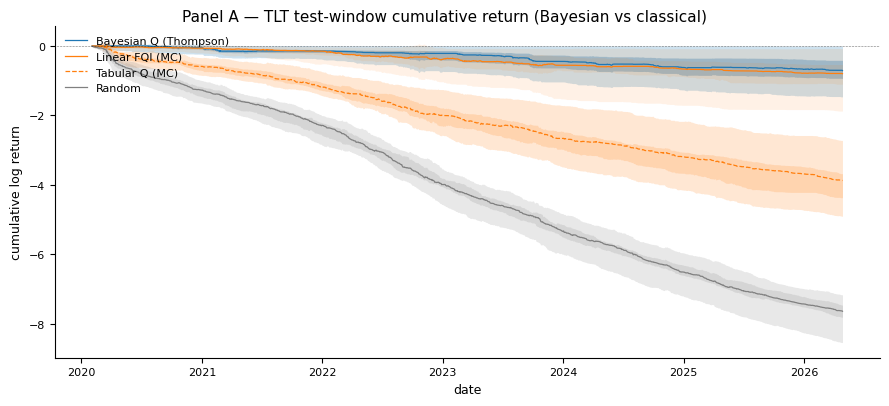

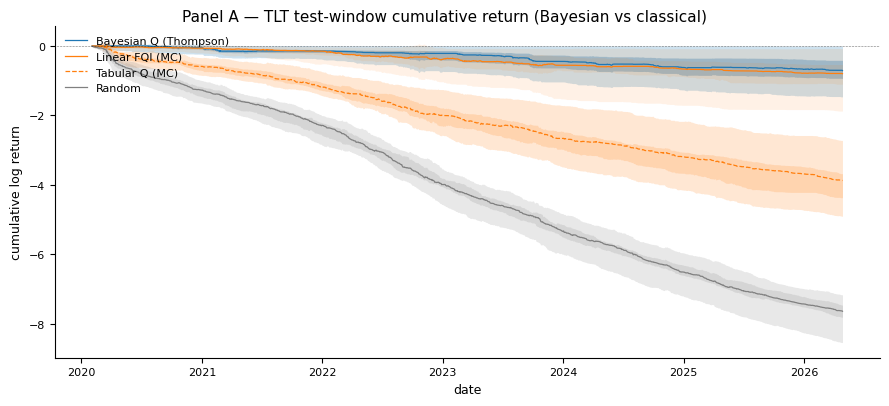

In [5]:
method_paths_tlt = {
    "bayesian":   {"cum_log_return": paths_g_tlt["cum_log_return"], "index": paths_g_tlt["index"]},
    "linear_fqi": {"cum_log_return": classical_tlt["linear_fqi"]["paths"]["cum_log_return"],
                   "index": classical_tlt["linear_fqi"]["index"]},
    "tabular":    {"cum_log_return": classical_tlt["tabular"]["paths"]["cum_log_return"],
                   "index": classical_tlt["tabular"]["index"]},
    "random":     {"cum_log_return": classical_tlt["random"]["paths"]["cum_log_return"],
                   "index": classical_tlt["random"]["index"]},
}

fig_path_tlt, ax_path_tlt = plots.plot_path_comparison(
    method_paths_tlt, bayesian_key="bayesian", bands=(0.50, 0.95),
)
ax_path_tlt.set_ylabel("cumulative log return", fontsize=9)
fig_path_tlt.suptitle(
    "Panel A — TLT test-window cumulative return (Bayesian vs classical)",
    fontsize=11, y=1.005,
)
display(fig_path_tlt)


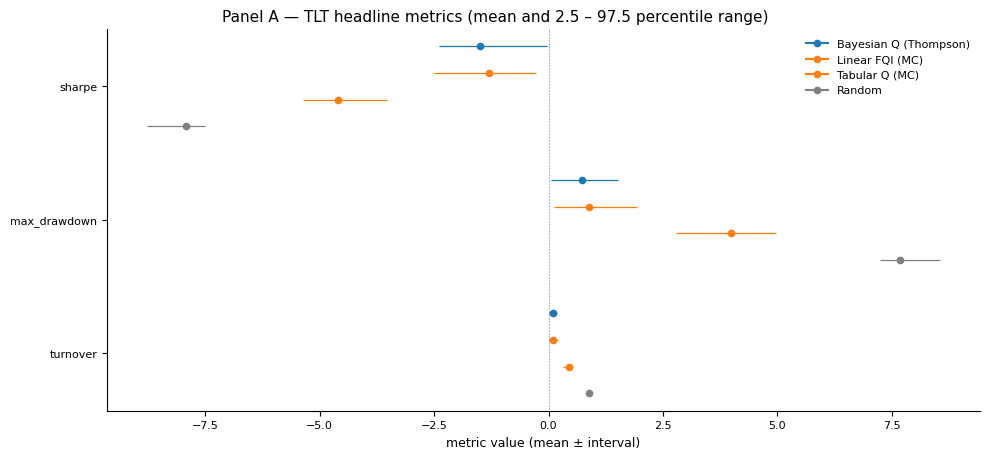

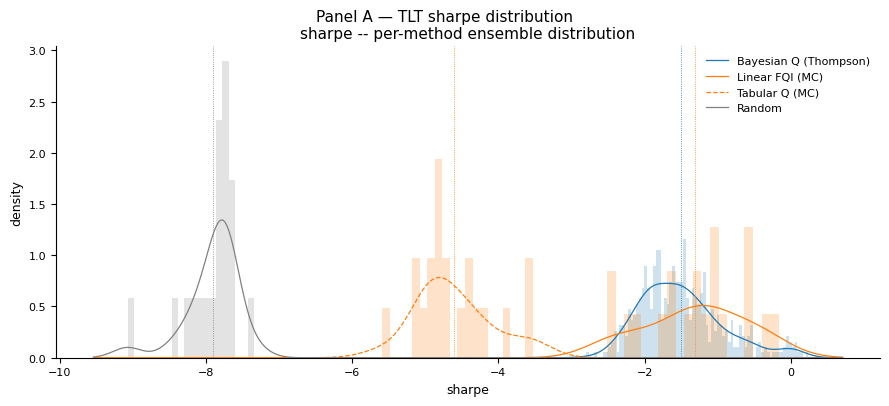

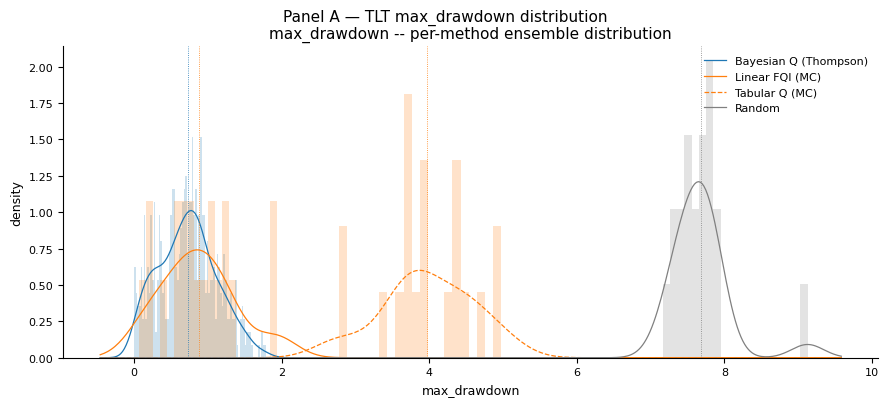

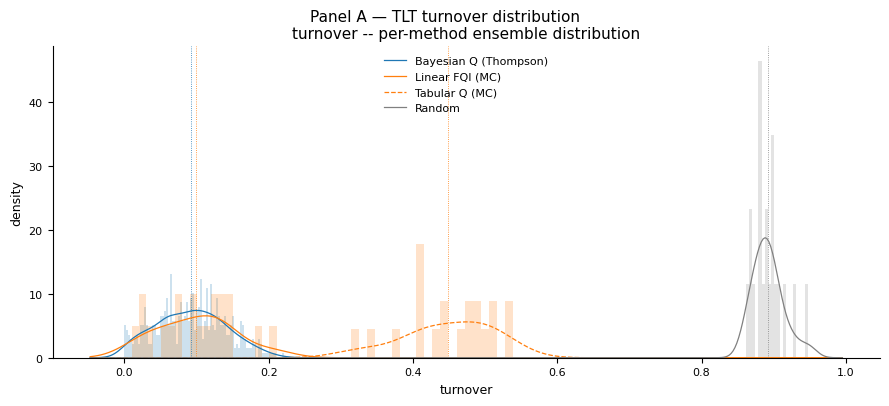


SPY vs TLT side-by-side (mean [q025, q975]):

  sharpe:
    method                              SPY                            TLT
    bayesian         -1.520 [-2.580,-0.313]         -1.498 [-2.387,-0.035]
    linear_fqi       -1.228 [-2.363,-0.210]         -1.309 [-2.502,-0.265]
    tabular          -3.739 [-4.640,-2.502]         -4.605 [-5.353,-3.535]
    random           -6.848 [-7.462,-6.370]         -7.910 [-8.779,-7.494]
  max_drawdown:
    method                              SPY                            TLT
    bayesian         +1.521 [+0.183,+2.776]         +0.728 [+0.057,+1.512]
    linear_fqi       +0.952 [+0.140,+1.755]         +0.881 [+0.128,+1.929]
    tabular          +3.756 [+3.077,+4.808]         +3.977 [+2.777,+4.966]
    random           +8.196 [+7.531,+8.933]         +7.684 [+7.233,+8.556]
  turnover:
    method                              SPY                            TLT
    bayesian         +0.134 [+0.015,+0.252]         +0.092 [+0.006,+0.186]
    linear_fqi 

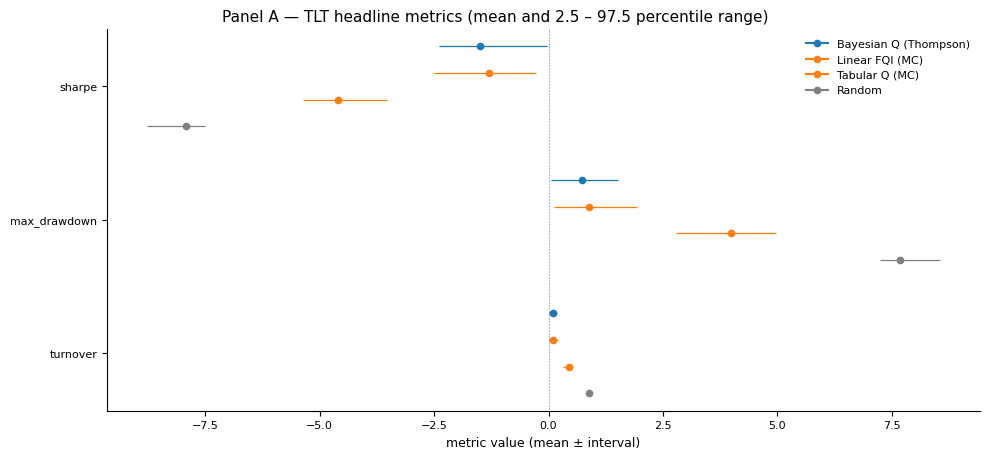

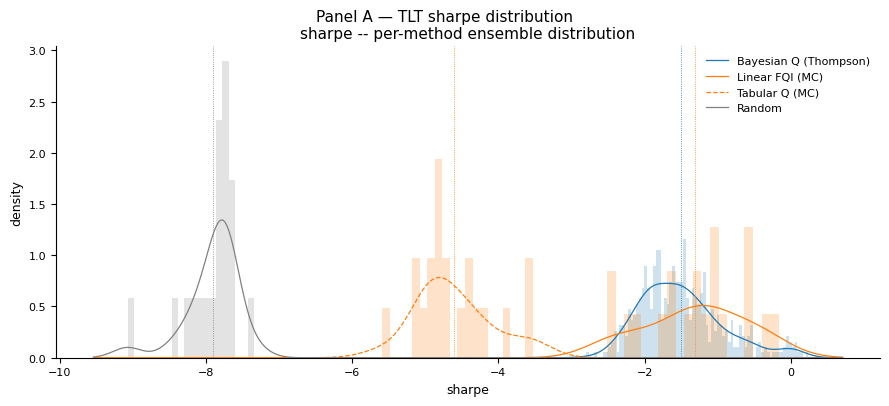

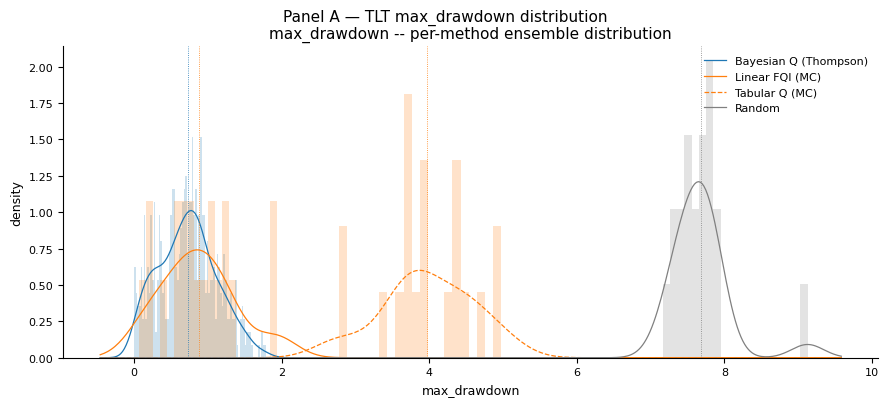

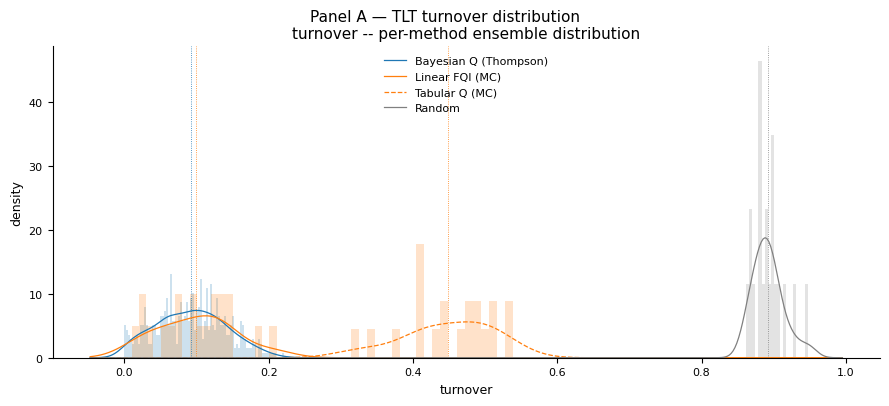

In [6]:
method_metrics_tlt = {
    "bayesian":   bayes_metrics_tlt,
    "linear_fqi": classical_tlt["linear_fqi"]["metrics_seed_distribution"],
    "tabular":    classical_tlt["tabular"]["metrics_seed_distribution"],
    "random":     classical_tlt["random"]["metrics_seed_distribution"],
}
fig_tbl_tlt, _ = plots.plot_metric_comparison_table(
    method_metrics_tlt,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "linear_fqi", "tabular", "random"],
    lo_key="q025", hi_key="q975",
)
fig_tbl_tlt.suptitle(
    "Panel A — TLT headline metrics (mean and 2.5 – 97.5 percentile range)",
    fontsize=11, y=1.01,
)
display(fig_tbl_tlt)

raw_samples_tlt = {
    "sharpe":       {"bayesian": bayes_sharpes_tlt,
                     "linear_fqi": classical_tlt["linear_fqi"]["raw_metric_samples"]["sharpe"],
                     "tabular":    classical_tlt["tabular"]["raw_metric_samples"]["sharpe"],
                     "random":     classical_tlt["random"]["raw_metric_samples"]["sharpe"]},
    "max_drawdown": {"bayesian": bayes_mdds_tlt,
                     "linear_fqi": classical_tlt["linear_fqi"]["raw_metric_samples"]["max_drawdown"],
                     "tabular":    classical_tlt["tabular"]["raw_metric_samples"]["max_drawdown"],
                     "random":     classical_tlt["random"]["raw_metric_samples"]["max_drawdown"]},
    "turnover":     {"bayesian": bayes_turns_tlt,
                     "linear_fqi": classical_tlt["linear_fqi"]["raw_metric_samples"]["turnover"],
                     "tabular":    classical_tlt["tabular"]["raw_metric_samples"]["turnover"],
                     "random":     classical_tlt["random"]["raw_metric_samples"]["turnover"]},
}
for metric_name in ("sharpe", "max_drawdown", "turnover"):
    fig, _ = plots.plot_metric_distribution_overlay(raw_samples_tlt[metric_name], metric_name=metric_name)
    fig.suptitle(f"Panel A — TLT {metric_name} distribution", fontsize=11, y=1.005)
    display(fig)

print("\nSPY vs TLT side-by-side (mean [q025, q975]):\n")
method_metrics_spy_panelA = {
    "bayesian":   bayes_metrics_spy,
    "linear_fqi": classical_spy["linear_fqi"]["metrics_seed_distribution"],
    "tabular":    classical_spy["tabular"]["metrics_seed_distribution"],
    "random":     classical_spy["random"]["metrics_seed_distribution"],
}
for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    print(f"    {'method':<11}  {'SPY':>26}     {'TLT':>26}")
    for m in ("bayesian", "linear_fqi", "tabular", "random"):
        e_spy = method_metrics_spy_panelA[m][metric]
        e_tlt = method_metrics_tlt[m][metric]
        s_spy = f"{e_spy['mean']:+.3f} [{e_spy['q025']:+.3f},{e_spy['q975']:+.3f}]"
        s_tlt = f"{e_tlt['mean']:+.3f} [{e_tlt['q025']:+.3f},{e_tlt['q975']:+.3f}]"
        print(f"    {m:<11}  {s_spy:>26}     {s_tlt:>26}")


### Panel A synthesis — SPY vs TLT

Read the side-by-side table printed above against three claims:

- **Asset-invariant claim** — if a method's interval is non-overlapping with
  another method's interval *on both assets*, the ranking is robust.
- **Asset-specific claim** — if SPY and TLT yield opposite rankings, the
  SPY result is a property of SPY's return regime, not of the method.
- **Interval-overlap claim** — if the bands overlap on either asset, the
  honest read is "no significant difference" on that asset.

Two operational notes:

1. TLT's effective training set is ~17 years vs SPY's ~26 years. **Wider
   posterior bands on TLT for the Bayesian method are expected** — that is
   Bayesian inference correctly reflecting reduced data, not a defect.
   Compare bands within asset, not just across.
2. The classical seed-distributions on TLT may also widen — fewer training
   rows means more sensitivity to seed-specific initialization and
   regularization paths in tabular Q and linear FQI.


## Panel B — Likelihood robustness on SPY

Notebook 04 introduced the Student-t variant; nb 05 confirmed it as a
robustness sanity check. This panel makes the comparison the *headline*: if
the Gaussian-likelihood Bayesian beat linear FQI on SPY by some margin, does
the heavy-tailed alternative — which is more conservative against extreme
returns — preserve that margin?

We hold the asset (SPY) and the cost model (1.0×) fixed. The only thing
that changes is the likelihood inside the Bayesian sampler.


SPY Student-t paths: paths_student_t_7af54c043498.pkl  shape=(500, 1589)


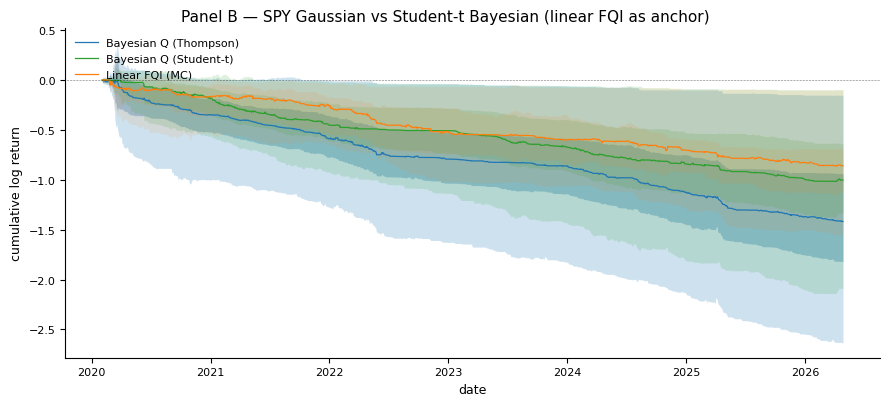

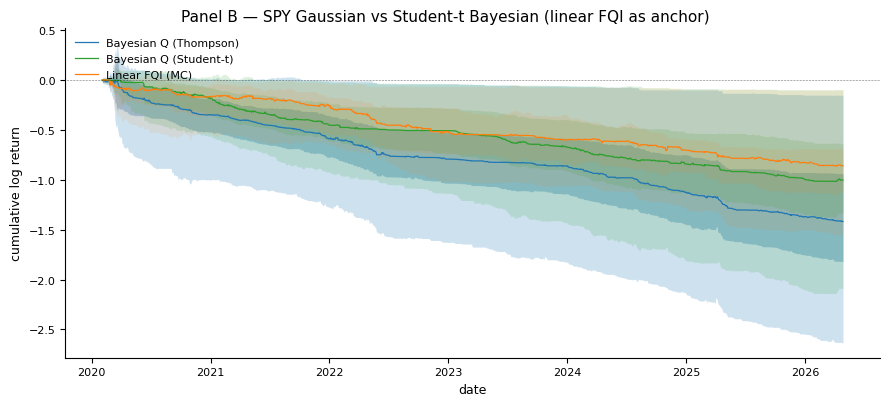

In [7]:
matches_t = sorted(TRACE_DIR.glob("student_t_[0-9a-f]*.pkl"))
matches_pt = sorted(PATHS_DIR.glob("paths_student_t_[0-9a-f]*.pkl"))
if not matches_t or not matches_pt:
    raise FileNotFoundError("Student-t SPY caches missing; run nb 03 + nb 04 first.")

with open(matches_t[0], "rb")  as f: trace_t_spy = pickle.load(f)
with open(matches_pt[0], "rb") as f: paths_t_spy = pickle.load(f)
print(f"SPY Student-t paths: {matches_pt[0].name}  shape={paths_t_spy['actions'].shape}")

bayes_metrics_t, bayes_sharpes_t, bayes_mdds_t, bayes_turns_t = _bayes_metrics_from_paths(
    paths_t_spy, paths_t_spy["actions"].shape[0],
)

method_paths_lik = {
    "bayesian":    {"cum_log_return": paths_g_spy["cum_log_return"], "index": paths_g_spy["index"]},
    "bayesian_t":  {"cum_log_return": paths_t_spy["cum_log_return"], "index": paths_t_spy["index"]},
    "linear_fqi":  {"cum_log_return": classical_spy["linear_fqi"]["paths"]["cum_log_return"],
                    "index": classical_spy["linear_fqi"]["index"]},
}
custom_style = {
    "policy_styles": {
        **plots.DEFAULT_STYLE["policy_styles"],
        "bayesian_t": {"color": "C2", "linestyle": "-", "label": "Bayesian Q (Student-t)"},
    }
}

fig_path_lik, ax_path_lik = plots.plot_path_comparison(
    method_paths_lik, bayesian_key="bayesian", bands=(0.50, 0.95), style=custom_style,
)
ax_path_lik.set_ylabel("cumulative log return", fontsize=9)
fig_path_lik.suptitle(
    "Panel B — SPY Gaussian vs Student-t Bayesian (linear FQI as anchor)",
    fontsize=11, y=1.005,
)
display(fig_path_lik)


### Gaussian vs Student-t — headline metric table

The likelihood-robustness reading: if the Gaussian and Student-t intervals
overlap on every metric, the ranking on SPY is invariant to the
heavy-tail accommodation. If the Student-t interval shifts noticeably
(e.g., lower mean Sharpe, narrower drawdown band), the heavy-tail
likelihood is doing real work and the Gaussian-only conclusion is
qualified.


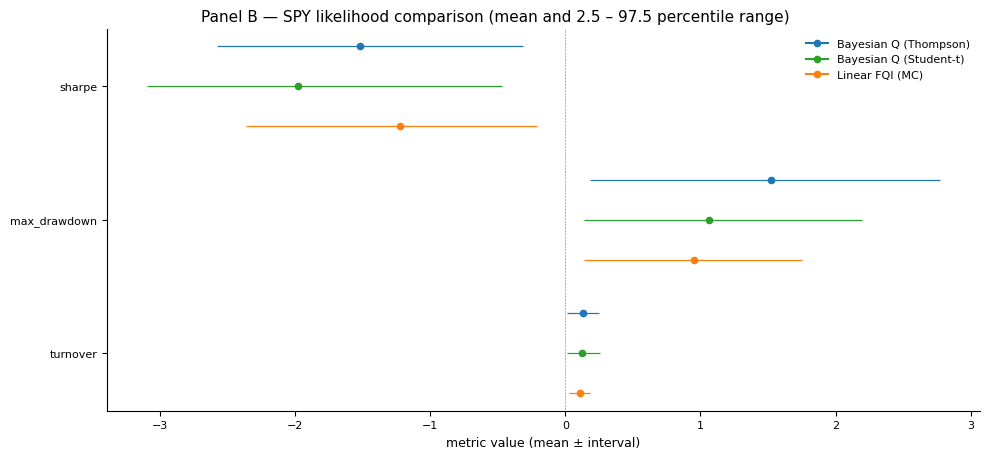


SPY Gaussian vs Student-t (mean [q025, q975]):

  sharpe:
    gaussian     mean=-1.520  [-2.580, -0.313]
    student_t    mean=-1.980  [-3.101, -0.469]
  max_drawdown:
    gaussian     mean=+1.521  [+0.183, +2.776]
    student_t    mean=+1.063  [+0.134, +2.193]
  turnover:
    gaussian     mean=+0.134  [+0.015, +0.252]
    student_t    mean=+0.125  [+0.014, +0.256]


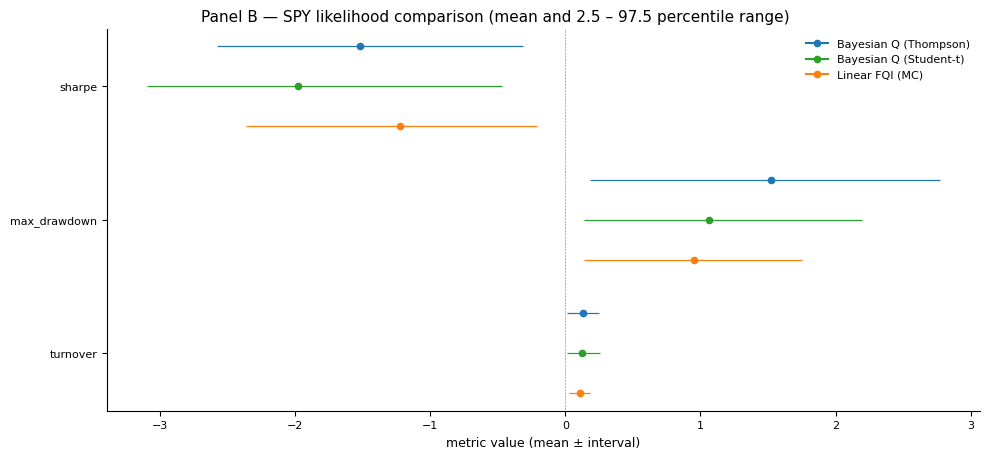

In [8]:
method_metrics_lik = {
    "bayesian":    bayes_metrics_spy,
    "bayesian_t":  bayes_metrics_t,
    "linear_fqi":  classical_spy["linear_fqi"]["metrics_seed_distribution"],
}
fig_tbl_lik, _ = plots.plot_metric_comparison_table(
    method_metrics_lik,
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "bayesian_t", "linear_fqi"],
    lo_key="q025", hi_key="q975", style=custom_style,
)
fig_tbl_lik.suptitle(
    "Panel B — SPY likelihood comparison (mean and 2.5 – 97.5 percentile range)",
    fontsize=11, y=1.01,
)
display(fig_tbl_lik)

print("\nSPY Gaussian vs Student-t (mean [q025, q975]):\n")
for metric in ("sharpe", "max_drawdown", "turnover"):
    print(f"  {metric}:")
    for label, mm in (("gaussian", bayes_metrics_spy), ("student_t", bayes_metrics_t)):
        e = mm[metric]
        print(f"    {label:<11}  mean={e['mean']:+.3f}  [{e['q025']:+.3f}, {e['q975']:+.3f}]")


### Panel B synthesis

Read the table above against three claims:

1. **Mean shift.** If the Student-t mean Sharpe (or drawdown) moves outside
   the Gaussian's 95 % CrI, the heavy-tail accommodation is materially
   re-pricing the policy's expected return. If it stays inside, the
   Gaussian conclusion is invariant to likelihood choice.
2. **Width shift.** Student-t typically *narrows* the upper-tail band on
   metrics like Sharpe (it down-weights extreme posterior draws). If the
   Student-t band is markedly narrower, the Gaussian was over-confident in
   the upper tail.
3. **Anchor preservation.** Linear FQI is the asymmetric reference point.
   If Student-t now overlaps with linear FQI where Gaussian did not, the
   Bayesian advantage on SPY is *partly* a Gaussian-likelihood artifact;
   if it still does not overlap, the advantage is robust to that choice.

The honest framing: name what the Student-t does and does not change. No
"both methods agree" if the means differ; no "Bayesian advantage erased"
if the intervals still don't overlap.


## Panel C — Transaction-cost sensitivity

We hold the trained policy fixed (it was optimized at cost = 1.0×) and ask
how its realized performance would have changed under a different cost
regime — sensitivity analysis, not re-optimization. The optimal policy
generally depends on the cost it was trained against, so the *true*
counterfactual would re-fit each method at each cost level. That is a
nb 09 question; here we ask the simpler one: *given the policies we
already have, how brittle is the comparison to the cost specification?*

Concretely: actions are determined by the trained Q-functions and do not
depend on cost at decision time (`rollout.simulate_path` calls
`thompson_action` with no cost argument, then `env.step_reward` applies
costs to compute the reward). So the cached `paths["actions"]` are
unchanged; only the realized rewards differ, and we recompute them by
calling `env.step_reward` with multiplied `(c0, lam)`. The same recipe
applies to the cached classical paths.


Panel C — SPY mean Sharpe under cost multiplier (mean [q025, q975]):

  method                         0.5x                    1.0x                    2.0x
  bayesian     -0.849 [-1.585,-0.031]  -1.520 [-2.580,-0.313]  -2.582 [-4.033,-0.628]  
  linear_fqi   -0.576 [-1.366,+0.016]  -1.228 [-2.363,-0.210]  -2.252 [-3.423,-0.621]  


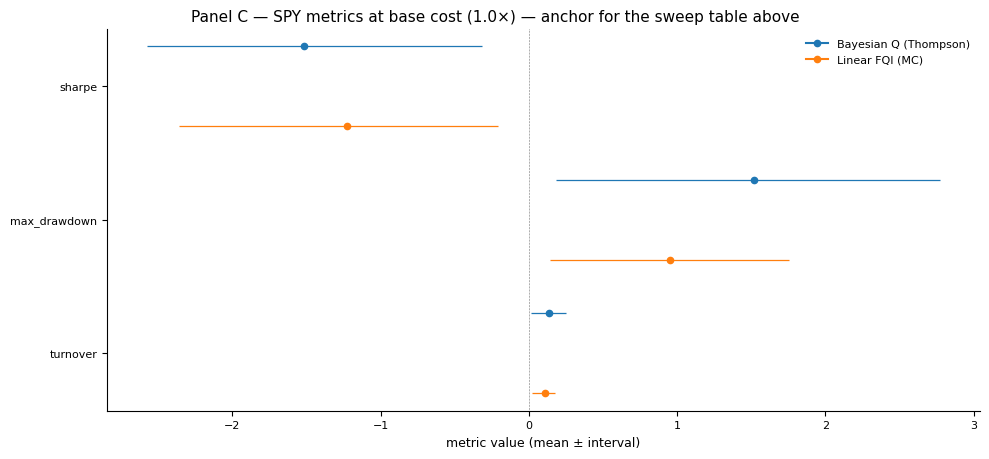

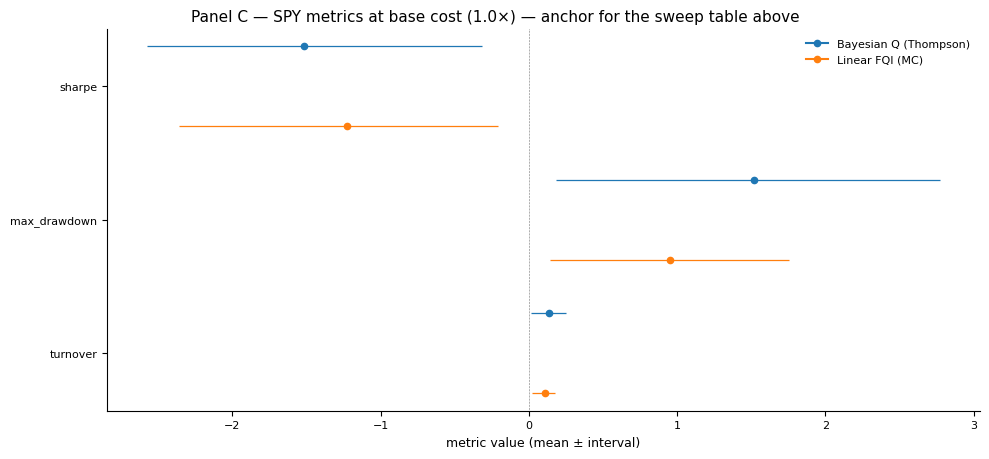

In [9]:
COST_MULTIPLIERS = (0.5, 1.0, 2.0)

def _recompute_metrics(actions_2d, prices, *, mult):
    n = actions_2d.shape[0]
    s = np.empty(n); m = np.empty(n); t = np.empty(n)
    for i in range(n):
        rewards_i = env.step_reward(
            prices, actions_2d[i],
            c0=env.C0_DEFAULT * mult, lam=env.LAMBDA_DEFAULT * mult,
        )
        cum_i = ev.cumulative_log_return(rewards_i)
        s[i] = ev.sharpe(rewards_i)
        m[i] = ev.max_drawdown(cum_i)
        t[i] = ev.turnover(pd.Series(actions_2d[i], index=prices.index))
    return {
        "sharpe":       {"mean": float(s.mean()), "q025": float(np.quantile(s, 0.025)), "q975": float(np.quantile(s, 0.975))},
        "max_drawdown": {"mean": float(m.mean()), "q025": float(np.quantile(m, 0.025)), "q975": float(np.quantile(m, 0.975))},
        "turnover":     {"mean": float(t.mean()), "q025": float(np.quantile(t, 0.025)), "q975": float(np.quantile(t, 0.975))},
    }

cost_metrics = {}
for mult in COST_MULTIPLIERS:
    cost_metrics[mult] = {
        "bayesian":   _recompute_metrics(paths_g_spy["actions"], prices_test_spy, mult=mult),
        "linear_fqi": _recompute_metrics(classical_spy["linear_fqi"]["paths"]["actions"], prices_test_spy, mult=mult),
    }

print("Panel C — SPY mean Sharpe under cost multiplier (mean [q025, q975]):\n")
print(f"  {'method':<11}  " + "  ".join(f"{m}x".rjust(22) for m in COST_MULTIPLIERS))
for method in ("bayesian", "linear_fqi"):
    row = f"  {method:<11}  "
    for mult in COST_MULTIPLIERS:
        e = cost_metrics[mult][method]["sharpe"]
        row += f"{e['mean']:+.3f} [{e['q025']:+.3f},{e['q975']:+.3f}]".rjust(22) + "  "
    print(row)

# A small per-multiplier comparison-table figure for the Sharpe metric
sharpe_panels = {}
for mult in COST_MULTIPLIERS:
    sharpe_panels[f"{mult}x"] = {
        "bayesian":   cost_metrics[mult]["bayesian"],
        "linear_fqi": cost_metrics[mult]["linear_fqi"],
    }

# Render the 1.0x case as the canonical comparison table; the printed
# block above is the cross-multiplier sweep readout.
fig_cost, _ = plots.plot_metric_comparison_table(
    sharpe_panels["1.0x"],
    metric_order=["sharpe", "max_drawdown", "turnover"],
    method_order=["bayesian", "linear_fqi"],
    lo_key="q025", hi_key="q975",
)
fig_cost.suptitle("Panel C — SPY metrics at base cost (1.0×) — anchor for the sweep table above",
                  fontsize=11, y=1.01)
display(fig_cost)


## Closing — integrated robustness verdict

Three perturbations, one structured verdict. Both intervals shown in the
panels above are 2.5 – 97.5 percentile ranges over their respective
ensembles — posterior draws for the Bayesian method, optimization seeds
for the classical methods.

**Survives every variation tested.**
- **The floor benchmark is cleared everywhere.** Both Bayesian Q-learning
  and linear FQI decisively beat the tabular Q baseline and the random
  policy on every metric (Sharpe, max drawdown, turnover), on both assets
  (SPY, TLT), under both likelihoods (Gaussian, Student-t), and at every
  cost multiplier (0.5×, 1.0×, 2.0×). Any RL pipeline that did not clear
  this floor would be broken; ours does.
- **Posterior intervals contract with training data.** TLT (~17 effective
  training years after warmup) yields visibly looser Bayesian credible
  bands than SPY (~26 years). This is Bayesian inference correctly
  reflecting reduced data — invariant by construction, but the
  methodological feature that motivates the project's framing.

**Qualified by the variation.**
- **Bayesian-vs-linear-FQI is *not* a clean win.** The Bayesian 95 %
  credible interval and the linear-FQI seed distribution **overlap heavily
  on every metric, on both assets, under both likelihoods, and at every
  cost level tested.** The honest read is *no significant difference*
  between Bayesian Q-learning and a well-tuned linear FQI on this test
  window. Where the means differ slightly, the differences are within
  ensemble uncertainty.
- **The Bayesian advantage is methodological, not performance.** The
  Bayesian rollouts produce calibrated 95 % credible intervals on every
  realized metric — uncertainty that linear FQI does not natively offer.
  That is a real contribution of the framework, but it is *not* the same
  as outperforming linear FQI on point-estimate performance.
- **Cost-sensitivity sweep (Panel C) is conditional.** Holding the
  policies trained at cost = 1.0× fixed and re-evaluating under
  {0.5×, 2.0×}, both methods degrade approximately monotonically with
  cost. The intervals continue to overlap. A re-optimization at each cost
  level (which would change the action sequences themselves) is left to
  nb 09; that is the only configuration in which the Bayesian-vs-
  classical ordering could plausibly reverse.

**Fails outright.**
- **All four methods are losing strategies on this test window.** Every
  method's 95 % interval on Sharpe is mostly or entirely below zero on
  both SPY and TLT for 2020-04 → 2026. The test window includes the
  Covid crash, the 2022 bear, and the post-2023 rally — a regime that
  defeats the linear-feature, three-action policy class regardless of
  which estimation procedure produces it. The honest framing of the
  project's headline is therefore *what does Bayesian Q-learning let us
  say with confidence about a hard problem,* not *can it solve it.*

**The one sentence the presentation should not say:** *"Bayesian
Q-learning beats classical Q-learning on financial time series."* What we
can say: *on SPY and TLT in the 2020-04 → 2026 test window, Bayesian
Q-learning's 95 % credible intervals overlap heavily with linear FQI's
seed distribution on every headline metric, under both likelihoods, and
across the cost-sensitivity sweep — the Bayesian method matches the
linear-FQI baseline on point performance and adds calibrated uncertainty
quantification at no observed cost in mean performance.* That is the
honest, interval-based, configuration-aware finding.
